In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [13]:
# memory
taco_dense_mem = pd.read_csv("./results/taco_dense_mem.csv")
taco_sparse_mem = pd.read_csv("./results/taco_csr_mem.csv")
taco_sparse_opt_mem = pd.read_csv("./results/taco_csr_mem.csv")
bitmap_mem = pd.read_csv("./results/bitmap_mem.csv")
bitmap_parallel_mem = pd.read_csv("./results/bitmap_parallel_mem.csv")
# runtime
taco_dense_run = pd.read_csv("./results/taco_dense_run.csv")
taco_sparse_run = pd.read_csv("./results/taco_csr_seq_run.csv")
taco_sparse_opt_run = pd.read_csv("./results/taco_csr_opt_run.csv")
bitmap_run = pd.read_csv("./results/bitmap_run.csv")
bitmap_parallel_run = pd.read_csv("./results/bitmap_parallel_run.csv")

In [14]:
%%capture
%run ./runtime.ipynb
%run ./mem.ipynb

In [15]:
mem_frames = [
    format_mem(taco_dense_mem, "dense"),
    format_mem(taco_sparse_mem, "sparse"),
    format_mem(taco_sparse_opt_mem, "human"),
    format_mem(bitmap_mem, "bitmap"),
    format_mem(bitmap_parallel_mem, "bitmap_parallel"),
]

In [16]:
run_frames = [
    format_runtime(taco_dense_run, "dense"),
    format_runtime(taco_sparse_run, "sparse"),
    format_runtime(taco_sparse_opt_run, "human"),
    format_runtime(bitmap_run, "bitmap"),
    format_runtime(bitmap_parallel_run, "bitmap_parallel"),
]

In [17]:
mem_df = pd.concat(mem_frames)
run_df = pd.concat(run_frames)

In [18]:
mem_df[mem_df["M"] == 2048]

,M,K,bytes,file,kernel,sparsity,mb
0,2048,2048,100663296,./dataset/2048_2048_80.tns,dense,20,96.000000
7,2048,2048,100663296,./dataset/2048_2048_50.tns,dense,50,96.000000
15,2048,2048,100663296,./dataset/2048_2048_70.tns,dense,30,96.000000
28,2048,2048,100663296,./dataset/2048_2048_60.tns,dense,40,96.000000
29,2048,2048,100663296,./dataset/2048_2048_10.tns,dense,90,96.000000
30,2048,2048,100663296,./dataset/2048_2048_20.tns,dense,80,96.000000
31,2048,2048,100663296,./dataset/2048_2048_90.tns,dense,10,96.000000
32,2048,2048,100663296,./dataset/2048_2048_40.tns,dense,60,96.000000
34,2048,2048,100663296,./dataset/2048_2048_30.tns,dense,70,96.000000
0,2048,2048,105796268,./dataset/2048_2048_80.tns,sparse,20,100.895184


In [19]:
run_df = run_df.groupby(['kernel', 'sparsity', 'M', 'K'], as_index=False)['time'].mean()

In [20]:
merged = pd.merge(run_df, mem_df[['kernel', 'M', 'K', 'sparsity', 'file', 'mb']], on=['kernel', 'M', 'K', 'sparsity'], how='left')
full_df = merged[['M', 'K', 'time', 'kernel', 'sparsity', 'mb']]
full_df = full_df.sort_values(by=['M', 'sparsity'])
full_df = full_df[(full_df["M"] == 4096) & (full_df["sparsity"] == 50)]

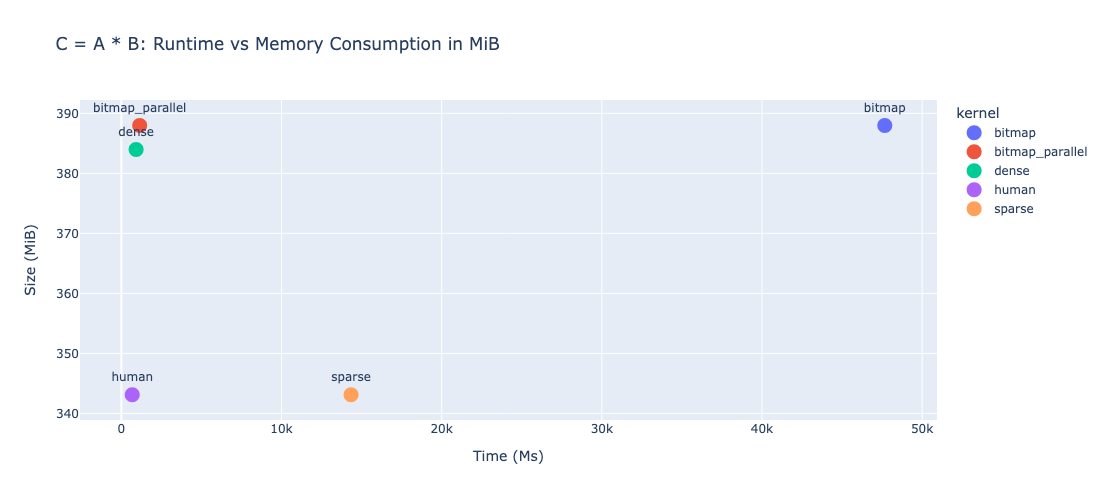

In [21]:
fig = px.scatter(full_df, 
      x='time', 
      y='mb',
      hover_data=["time", "mb"],
      color='kernel',
      text='kernel',
      title='C = A * B: Runtime vs Memory Consumption in MiB',
      labels={'time': 'Time (Ms)', 'mb': 'Size (MiB)'},
      width=800, height=500,
)
fig.update_traces(marker_size=15, textposition='top center')
fig.show()